## Correlation Analysis — NIFTY 50 Stocks

### Objective
Identify highly correlated stock pairs from the NIFTY 50 universe to reduce the search space for cointegration testing.

Correlation is computed using **log returns** rather than prices to ensure stationarity.

### Steps
1. Load cleaned price dataset
2. Compute log returns
3. Compute correlation matrix
4. Visualize correlation structure
5. Extract top correlated pairs
6. Filter strong candidate pairs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Cleaned Price Data

The dataset generated in the previous notebook is loaded from the processed data folder.


In [2]:
close_prices = pd.read_csv("../data/processed/nifty50_close_prices.csv", index_col="Date", parse_dates=True)

print("Dataset shape:", close_prices.shape)
close_prices.head()
print("Number of stocks:", close_prices.shape[1])
print("Number of observations:", close_prices.shape[0])


Dataset shape: (2061, 49)
Number of stocks: 49
Number of observations: 2061


In [3]:
# Check for missing values
print("Missing values:", close_prices.isna().sum().sum())


Missing values: 0


### Compute Log Returns

Correlation should be computed on returns rather than prices.
Log returns are used because they are additive and more suitable for statistical modeling.


In [4]:
log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns.dropna()

log_returns.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,BAJAJHLDNG.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2017-11-20,0.023976,-0.005878,0.004493,-0.004235,0.005057,0.010901,0.009965,0.008502,0.005858,0.002308,...,-0.013423,0.000097,-0.001423,0.056111,0.001354,-0.016123,-0.002993,-0.020301,0.006469,-0.002714
2017-11-21,-0.044296,0.005504,0.044484,-0.005201,0.003022,0.017808,0.002490,0.006291,-0.012878,0.005756,...,-0.007082,0.039618,-0.011346,-0.006386,0.013017,0.035135,0.039395,-0.004290,0.034519,-0.001190
2017-11-22,0.027954,0.033610,0.036951,0.011994,-0.011588,0.003916,-0.019980,-0.005750,0.016211,0.002761,...,0.013965,-0.005218,0.002876,0.003289,-0.000422,-0.023044,-0.002825,0.015964,-0.009856,0.001020
2017-11-23,-0.034164,-0.018014,-0.008694,-0.012597,0.006731,-0.014762,-0.005823,-0.008293,0.036744,0.009898,...,-0.001044,0.017593,0.000224,0.002733,0.002318,0.014401,-0.008956,-0.010754,0.002807,-0.002552
2017-11-24,0.004906,-0.006160,0.004946,0.000000,0.002478,0.007218,0.014830,0.005246,-0.013181,-0.001850,...,-0.007642,0.008682,0.002533,0.014093,-0.005981,0.009149,0.028622,0.013327,-0.006898,-0.002900


In [5]:
corr_matrix = log_returns.corr()

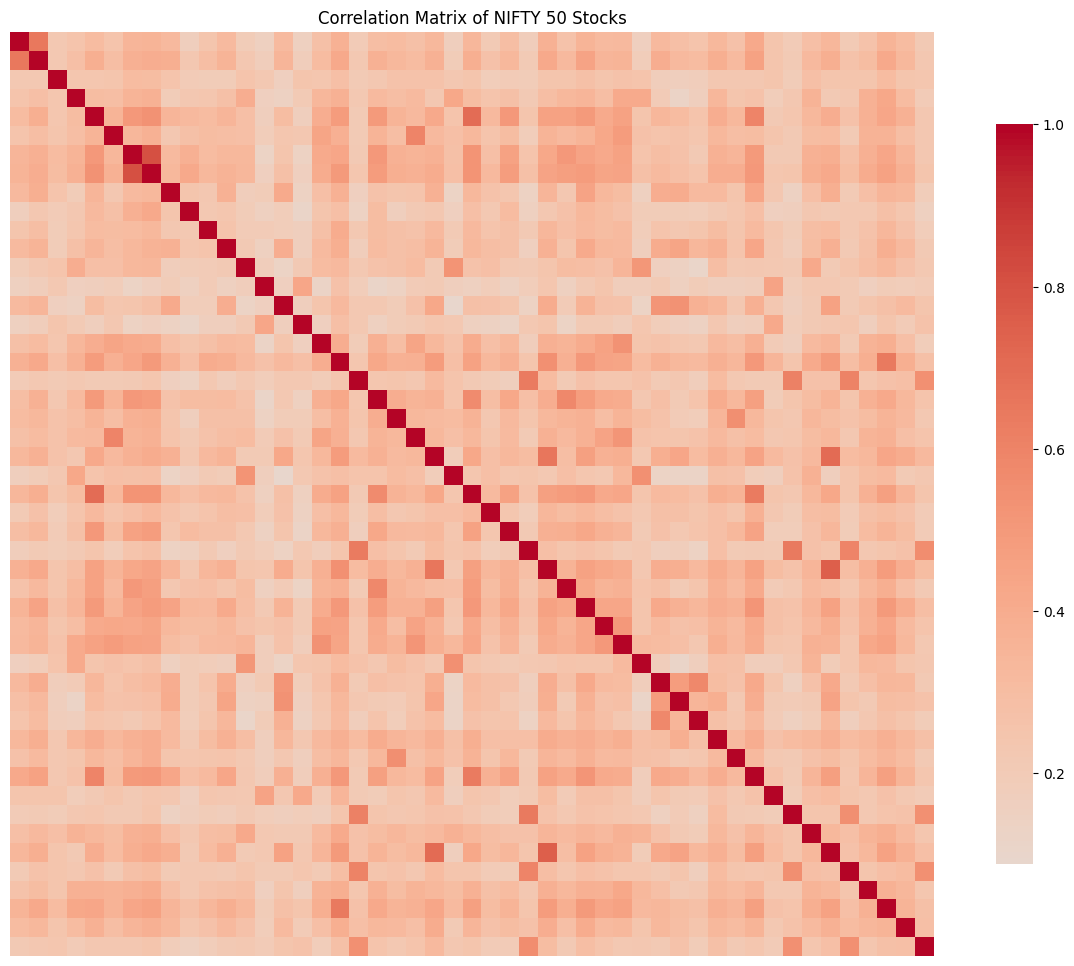

In [6]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink":0.8},
    xticklabels=False,
    yticklabels=False
)

plt.title("Correlation Matrix of NIFTY 50 Stocks")
plt.savefig("../reports/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### Extract Unique Stock Pairs

The correlation matrix contains duplicate information.
We extract only the **upper triangular portion** to obtain unique stock pairs and then sort them by correlation strength.


In [7]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

top_pairs = corr_pairs.head(10)

print("\nTop 10 Correlated Stock Pairs\n")
print(top_pairs)



Top 10 Correlated Stock Pairs

BAJFINANCE.NS  BAJAJFINSV.NS    0.810585
JSWSTEEL.NS    TATASTEEL.NS     0.750925
HINDALCO.NS    TATASTEEL.NS     0.707816
AXISBANK.NS    ICICIBANK.NS     0.697590
HINDALCO.NS    JSWSTEEL.NS      0.654800
ADANIENT.NS    ADANIPORTS.NS    0.650612
INFY.NS        TCS.NS           0.640925
GRASIM.NS      ULTRACEMCO.NS    0.640739
HCLTECH.NS     INFY.NS          0.638100
ICICIBANK.NS   SBIN.NS          0.637859
dtype: float64


### Select Strongly Correlated Pairs

Pairs with correlation greater than **0.75** are considered strong candidates for cointegration testing in the next notebook.


In [8]:
strong_pairs = corr_pairs[corr_pairs > 0.75]

print("Strong correlation pairs:")
print(strong_pairs.head(20))

Strong correlation pairs:
BAJFINANCE.NS  BAJAJFINSV.NS    0.810585
JSWSTEEL.NS    TATASTEEL.NS     0.750925
dtype: float64


In [9]:
strong_pairs.to_csv("../data/processed/high_correlation_pairs.csv",header=["correlation"])

print("Strong correlation pairs saved successfully")


Strong correlation pairs saved successfully


### Output

The notebook produces:

• Correlation matrix visualization  
• Top correlated stock pairs  
• Strong candidate pairs for cointegration testing  

The strong pairs dataset is saved to:

data/processed/high_correlation_pairs.csv
